# Transformer Sentence Embeddings - Kaggle Training

## Pipeline (run cells top-to-bottom)

| Stage | Cell | Script | Output |
|-------|------|--------|--------|
| 1 | 4 | `train.py` | `best_model.pt`, `vocab.pkl` |
| 2 | 5 | `evaluate_search.py` | `data/train_hard_negatives.csv` |
| 3 | 6 | `train_triplet.py` | `final_hard_tuned_model.pt` |
| Eval | 7 | inline | Recall@K, MRR, Spearman |
| Demo | 8–9 | inline | Similarity scores |

## Before running
1. **Add your project as a dataset**: Upload your project folder (containing `train.py`, `data.py`, `models/`, `losses/`) as a Kaggle dataset, then attach it to this notebook.
2. **Set `PROJECT_DIR`** in Cell 2 to the dataset path (e.g. `/kaggle/input/transformer-sbert`).
3. **Enable GPU**: Settings → Accelerator → GPU T4
4. **Enable Internet**: Settings → Internet → On (needed for data download)

In [1]:
!pip install -q datasets scipy tqdm

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch : 2.9.1+cpu
CUDA    : False


In [2]:
import os, sys, shutil

# ── Set this to your Kaggle dataset path ──────────────────────────────────────
PROJECT_DIR = '/kaggle/input/transformer-sbert'   # <-- update to your dataset slug
# ─────────────────────────────────────────────────────────────────────────────

WORKING_DIR = '/kaggle/working'

if os.path.isdir(PROJECT_DIR):
    print(f'Copying project files from {PROJECT_DIR} ...')
    for item in os.listdir(PROJECT_DIR):
        src = os.path.join(PROJECT_DIR, item)
        dst = os.path.join(WORKING_DIR, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
    print('Done.')
else:
    print(f'PROJECT_DIR not found: {PROJECT_DIR}')
    print('Running from current directory (files must already be present).')

os.makedirs('data', exist_ok=True)
sys.path.insert(0, WORKING_DIR)
print(f'sys.path[0] = {sys.path[0]}')
print('Files in working dir:', [f for f in os.listdir(WORKING_DIR) if not f.startswith('.')][:20])

PROJECT_DIR not found: /kaggle/input/transformer-sbert
Running from current directory (files must already be present).
sys.path[0] = /kaggle/working


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/working'

In [ ]:
# ── Download STS-B dataset ────────────────────────────────────────────────────
import pandas as pd

try:
    from datasets import load_dataset
    splits = [
        ('train',      'data/stsb_train.csv'),
        ('validation', 'data/stsb_validation.csv'),
        ('test',       'data/stsb_test.csv'),
    ]
    for split, out in splits:
        if os.path.exists(out):
            print(f'{out} already exists, skipping.')
            continue
        df = load_dataset('mteb/stsbenchmark-sts', split=split).to_pandas()
        if 'score' not in df.columns and 'similarity_score' in df.columns:
            df = df.rename(columns={'similarity_score': 'score'})
        df[['sentence1', 'sentence2', 'score']].to_csv(out, index=False)
        lo, hi = df['score'].min(), df['score'].max()
        print(f'{out}: {len(df):,} rows  score=[{lo:.1f}, {hi:.1f}]')
    print('Data ready.')
except Exception as e:
    print(f'Download failed: {e}')
    print('Manually place stsb_train/validation/test.csv in data/')

In [ ]:
# ── Stage 1: MNR training ────────────────────────────────────────────────────
# Produces: best_model.pt  (best val Spearman checkpoint)
#           vocab.pkl      (vocabulary used by all downstream steps)
!python train.py

In [ ]:
# ── Stage 2: Mine hard negatives ─────────────────────────────────────────────
# Loads best_model.pt + vocab.pkl, encodes all training sentences, and finds
# the top-5 most similar non-positive pairs for each anchor.
# Produces: data/train_hard_negatives.csv
!python evaluate_search.py

In [ ]:
# ── Stage 3: TripletLoss fine-tuning on hard negatives ───────────────────────
# Loads best_model.pt + data/train_hard_negatives.csv, fine-tunes 5 epochs
# with TripletLoss (margin=0.5) at lr=5e-5.
# Produces: final_hard_tuned_model.pt
!python train_triplet.py

In [ ]:
# ── Evaluate final model (Recall@K, MRR, Spearman) ───────────────────────────
import pickle, torch
from evaluate_search import evaluate

with open('vocab.pkl', 'rb') as _vf:
    vocab = pickle.load(_vf)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EVAL_CONFIG = {
    'd_model':       256,
    'n_layers':      4,
    'n_heads':       4,
    'd_ff':          512,
    'max_len':       128,
    'pooling':       'mean',
    'pos_threshold': 0.65,
}

print('=== MNR model (best_model.pt) ===')
evaluate('best_model.pt', 'data/stsb_validation.csv', vocab, EVAL_CONFIG, DEVICE)

print('\n=== Hard-tuned model (final_hard_tuned_model.pt) ===')
evaluate('final_hard_tuned_model.pt', 'data/stsb_validation.csv', vocab, EVAL_CONFIG, DEVICE)

In [6]:
# ── Inference demo ────────────────────────────────────────────────────────────
import os, pickle
import torch
import torch.nn.functional as F

from models.model.transformer import Transformer

CONFIG = {
    'max_len':  128,
    'd_model':  256,
    'n_layers': 4,
    'n_heads':  4,
    'd_ff':     512,
    'pooling':  'mean',
    # Use the hard-tuned model if available, otherwise fall back to MNR model
    'save_path': 'best_model.pt',
}

with open('vocab.pkl', 'rb') as _vf:
    vocab = pickle.load(_vf)
print(f'Vocab loaded from vocab.pkl ({len(vocab):,} tokens)')

model = Transformer(
    vocab_size=len(vocab),
    d_model=CONFIG['d_model'],
    n_layers=CONFIG['n_layers'],
    n_heads=CONFIG['n_heads'],
    d_ff=CONFIG['d_ff'],
    max_len=CONFIG['max_len'],
    dropout=0.0,
    pooling=CONFIG['pooling'],
).to(DEVICE)

model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
model.eval()
print(f"Model loaded from {CONFIG['save_path']}")

Vocab loaded from vocab.pkl (85,415 tokens)
Model loaded from best_model.pt


Sentence 1                                         Sentence 2                                          Ground Truth  Model Pred    Diff
---------------------------------------------------------------------------------------------------------------------------------------
This church choir sings to the masses as they sing The church has cracks in the ceiling                      0.3666      0.5492  0.1826
This church choir sings to the masses as they sing The church is filled with song                            0.7207      0.9068  0.1861
This church choir sings to the masses as they sing A choir singing at a baseball game                        0.5411      0.7641  0.2229
A woman with a green headscarf, blue shirt and a v The woman is young                                        0.3382      0.6091  0.2709
A woman with a green headscarf, blue shirt and a v The woman is very happy                                   0.5396      0.9494  0.4098
A woman with a green headscarf, blue shirt and a

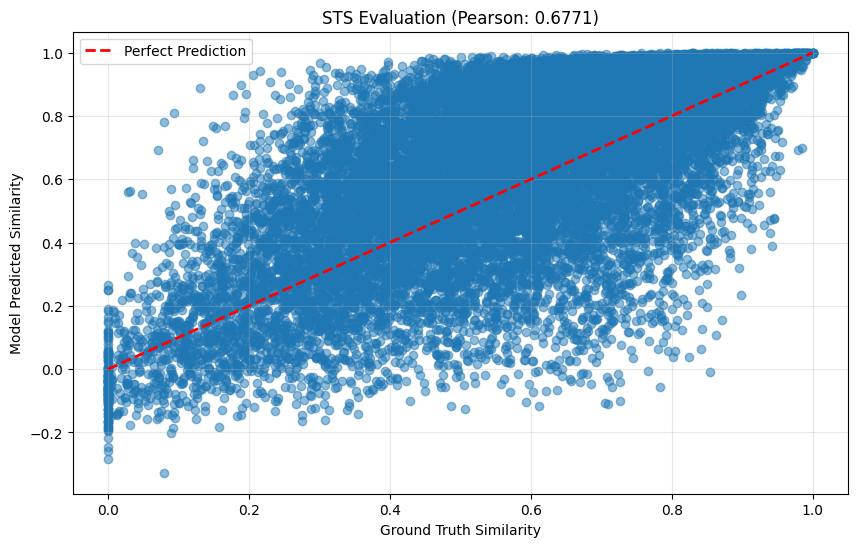

In [12]:
import csv
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

@torch.no_grad()
def embed(text):
    cls_id = vocab.word2idx[vocab.CLS_TOKEN]
    sep_id = vocab.word2idx[vocab.SEP_TOKEN]
    ids = torch.tensor(
        [[cls_id] + vocab.encode(text)[:CONFIG['max_len'] - 2] + [sep_id]],
        dtype=torch.long
    ).to(DEVICE)
    return model.encode(ids, normalize=True)

def similarity(t1, t2):
    return (embed(t1) * embed(t2)).sum().item()

# Load test pairs from CSV
test_pairs = []
ground_truth_scores = []

with open('data\\sts-222\\stsb_test.csv', 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_pairs.append((row['sentence1'], row['sentence2']))
        ground_truth_scores.append(float(row['score']))

# Compute model predictions
model_scores = []
print(f'{"Sentence 1":<50} {"Sentence 2":<50} {"Ground Truth":>13} {"Model Pred":>11} {"Diff":>7}')
print('-' * 135)

for s1, s2 in test_pairs:
    sim = similarity(s1, s2)
    model_scores.append(sim)

for (s1, s2), gt, pred in zip(test_pairs, ground_truth_scores, model_scores):
    diff = abs(gt - pred)
    print(f'{s1[:50]:<50} {s2[:50]:<50} {gt:>13.4f} {pred:>11.4f} {diff:>7.4f}')

# Calculate metrics
model_scores = np.array(model_scores)
ground_truth_scores = np.array(ground_truth_scores)

pearson_corr, pearson_pval = pearsonr(ground_truth_scores, model_scores)
spearman_corr, spearman_pval = spearmanr(ground_truth_scores, model_scores)
mae = np.mean(np.abs(ground_truth_scores - model_scores))

print('\n' + '='*95)
print(f'Pearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.2e})')
print(f'Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})')
print(f'Mean Absolute Error: {mae:.4f}')
print('='*95)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(ground_truth_scores, model_scores, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Ground Truth Similarity')
plt.ylabel('Model Predicted Similarity')
plt.title(f'STS Evaluation (Pearson: {pearson_corr:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('sts_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()